# ===================================================
# Machine Learning & Deep Learning
# ===================================================

In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ===================================================
# PART 1: DATA LOADING AND QUALITY REPORT
# ===================================================
print("\n" + "="*70)
print("STEP 1: DATA LOADING AND QUALITY ASSESSMENT")
print("="*70)

# Load the dataset
file_path = "security_access_risk_dataset_RNC.csv"
df = pd.read_csv(file_path)

print(f"Dataset loaded successfully from: {file_path}")
print(f"Initial dataset shape: {df.shape} rows × {df.shape[1]} columns")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

print("\n" + "-"*70)
print("DATA QUALITY CHECK (AS REQUIRED IN INSTRUCTIONS)")
print("-"*70)

# Check for missing values
missing_values = df.isnull().sum()
print("\n1. MISSING VALUES IDENTIFIED:")
for col, count in missing_values.items():
    if count > 0:
        print(f"   - '{col}': {count} missing values")

# Check for duplicates
duplicate_count = df.duplicated().sum()
print(f"\n2. DUPLICATE ROWS IDENTIFIED: {duplicate_count}")

# Check data types
print("\n3. DATA TYPES:")
print(df.dtypes)

print("\n" + "-"*70)
print("DATA CLEANING ACTIONS TAKEN")
print("-"*70)

# Store initial statistics
initial_rows = len(df)
initial_missing = df.isnull().sum().sum()


STEP 1: DATA LOADING AND QUALITY ASSESSMENT
Dataset loaded successfully from: security_access_risk_dataset_RNC.csv
Initial dataset shape: (1545, 5) rows × 5 columns

Column names: ['Failed_Attempts_Last30Days', 'Access_Time_Deviation', 'Entry_Distance_From_Usual', 'User_Access_Tier', 'Access_Risk_Score']

First 5 rows:
   Failed_Attempts_Last30Days  Access_Time_Deviation  \
0                         3.0                  16.30   
1                         0.0                  13.95   
2                         4.0                  30.83   
3                         3.0                  17.50   
4                         3.0                  11.93   

   Entry_Distance_From_Usual User_Access_Tier  Access_Risk_Score  
0                      41.03         Standard              68.10  
1                      31.86            Admin              43.55  
2                      36.13         Standard              85.70  
3                      51.10         Standard              66.51  
4     

In [4]:
# Action 1: Handle missing values
print("\nACTION 1: Handling missing values")
for column in df.columns:
    if df[column].isnull().sum() > 0:
        if df[column].dtype in ['int64', 'float64']:
            # For numeric columns, use median
            median_val = df[column].median()
            df[column] = df[column].fillna(median_val)
            print(f"   - '{column}': Filled {df[column].isnull().sum()} missing values with median ({median_val:.2f})")
        else:
            # For categorical, use mode
            mode_val = df[column].mode()[0]
            df[column] = df[column].fillna(mode_val)
            print(f"   - '{column}': Filled {df[column].isnull().sum()} missing values with mode ('{mode_val}')")

# Action 2: Remove duplicates
print("\nACTION 2: Removing duplicate rows")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"   - Removed {duplicate_count} duplicate rows")
else:
    print("   - No duplicates to remove")

print(f"\nDataset after cleaning: {len(df)} rows × {df.shape[1]} columns")
print(f"Missing values remaining: {df.isnull().sum().sum()}")


ACTION 1: Handling missing values
   - 'Failed_Attempts_Last30Days': Filled 0 missing values with median (2.00)
   - 'Access_Time_Deviation': Filled 0 missing values with median (14.71)
   - 'Entry_Distance_From_Usual': Filled 0 missing values with median (29.24)
   - 'User_Access_Tier': Filled 0 missing values with mode ('Standard')
   - 'Access_Risk_Score': Filled 0 missing values with median (51.72)

ACTION 2: Removing duplicate rows
   - Removed 45 duplicate rows

Dataset after cleaning: 1500 rows × 5 columns
Missing values remaining: 0


In [5]:
# ===================================================
# PART 2: DATA PREPARATION AND ENCODING
# ===================================================
print("\n" + "="*70)
print("STEP 2: DATA PREPARATION AND FEATURE ENGINEERING")
print("="*70)

# Check User_Access_Tier values
print("\nUser_Access_Tier unique values:")
print(df['User_Access_Tier'].unique())
print(f"Data type: {df['User_Access_Tier'].dtype}")

# CORRECT ENCODING: User_Access_Tier is ordinal (1=Standard, 2=Elevated, 3=Admin)
# Since it's already numeric, we keep it as is
print("\nENCODING DECISION:")
if df['User_Access_Tier'].dtype in ['int64', 'float64']:
    print("   - User_Access_Tier is already numeric (1, 2, 3). No encoding needed.")
    print("   - This preserves the ordinal relationship: Standard(1) < Elevated(2) < Admin(3)")
else:
    print("   - User_Access_Tier is categorical. Applying LabelEncoder to preserve ordinality.")
    le = LabelEncoder()
    df['User_Access_Tier'] = le.fit_transform(df['User_Access_Tier'])
    print(f"   - Encoded values: {le.classes_}")

# Separate features and target
X = df[['Failed_Attempts_Last30Days', 'Access_Time_Deviation', 
        'Entry_Distance_From_Usual', 'User_Access_Tier']]
y = df['Access_Risk_Score']

print(f"\nFeatures shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")

# Check target distribution
print("\nTarget variable (Access_Risk_Score) statistics:")
print(f"   Min: {y.min():.2f}")
print(f"   Max: {y.max():.2f}")
print(f"   Mean: {y.mean():.2f}")
print(f"   Std: {y.std():.2f}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain/Test Split (80/20):")
print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Testing set: {X_test.shape[0]} samples")


STEP 2: DATA PREPARATION AND FEATURE ENGINEERING

User_Access_Tier unique values:
['Standard' 'Admin' 'Elevated']
Data type: object

ENCODING DECISION:
   - User_Access_Tier is categorical. Applying LabelEncoder to preserve ordinality.
   - Encoded values: ['Admin' 'Elevated' 'Standard']

Features shape (X): (1500, 4)
Target shape (y): (1500,)

Target variable (Access_Risk_Score) statistics:
   Min: 0.01
   Max: 126.21
   Mean: 53.05
   Std: 20.23

Train/Test Split (80/20):
   Training set: 1200 samples
   Testing set: 300 samples


In [6]:
# ===================================================
# PART 3: FEATURE SCALING FOR DNN (REQUIRED)
# ===================================================
print("\n" + "="*70)
print("STEP 3: FEATURE SCALING FOR DNN MODEL")
print("="*70)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler:")
print(f"   Training mean after scaling: {X_train_scaled.mean():.4f}")
print(f"   Training std after scaling: {X_train_scaled.std():.4f}")
print("   (Close to 0 mean and 1 std indicates proper scaling)")


STEP 3: FEATURE SCALING FOR DNN MODEL
Features scaled using StandardScaler:
   Training mean after scaling: -0.0000
   Training std after scaling: 1.0000
   (Close to 0 mean and 1 std indicates proper scaling)


In [7]:
# ===================================================
# PART 4: MODEL 1 - DEEP NEURAL NETWORK (DNN-A)
# ===================================================
print("\n" + "="*70)
print("MODEL 1: DEEP NEURAL NETWORK (DNN-A)")
print("="*70)

print("DNN Architecture (as required: several hidden layers with several neurons):")
print("   - Input Layer: 4 neurons (matching 4 features)")
print("   - Hidden Layer 1: 64 neurons, ReLU activation")
print("   - Dropout Layer 1: 0.2 dropout rate")
print("   - Hidden Layer 2: 32 neurons, ReLU activation")
print("   - Dropout Layer 2: 0.2 dropout rate")
print("   - Hidden Layer 3: 16 neurons, ReLU activation")
print("   - Output Layer: 1 neuron (linear activation for regression)")

model_dnn = Sequential([
    Dense(64, activation='relu', input_shape=(4,)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model_dnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("\nTraining DNN with early stopping...")
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=0
)

history = model_dnn.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

print(f"Training completed after {len(history.history['loss'])} epochs")
print(f"Final training loss: {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")

# Make predictions
y_pred_dnn = model_dnn.predict(X_test_scaled).flatten()


MODEL 1: DEEP NEURAL NETWORK (DNN-A)
DNN Architecture (as required: several hidden layers with several neurons):
   - Input Layer: 4 neurons (matching 4 features)
   - Hidden Layer 1: 64 neurons, ReLU activation
   - Dropout Layer 1: 0.2 dropout rate
   - Hidden Layer 2: 32 neurons, ReLU activation
   - Dropout Layer 2: 0.2 dropout rate
   - Hidden Layer 3: 16 neurons, ReLU activation
   - Output Layer: 1 neuron (linear activation for regression)

Training DNN with early stopping...
Training completed after 46 epochs
Final training loss: 116.3139
Final validation loss: 74.4862
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step 


In [8]:
# ===================================================
# PART 5: MODEL 2 - RANDOM FOREST REGRESSOR
# ===================================================
print("\n" + "="*70)
print("MODEL 2: RANDOM FOREST REGRESSOR")
print("="*70)

print("Random Forest Configuration:")
print("   - Number of trees: 100")
print("   - Random state: 42 (for reproducibility)")
print("   - No feature scaling needed (tree-based algorithm)")

model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("Random Forest training completed.")

# Feature importance analysis
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance Analysis:")
for idx, row in feature_importance.iterrows():
    print(f"   {row['Feature']}: {row['Importance']*100:.1f}%")


MODEL 2: RANDOM FOREST REGRESSOR
Random Forest Configuration:
   - Number of trees: 100
   - Random state: 42 (for reproducibility)
   - No feature scaling needed (tree-based algorithm)
Random Forest training completed.

Feature Importance Analysis:
   Failed_Attempts_Last30Days: 39.8%
   Entry_Distance_From_Usual: 26.7%
   Access_Time_Deviation: 21.3%
   User_Access_Tier: 12.2%


In [9]:
# ===================================================
# PART 6: PERFORMANCE EVALUATION
# ===================================================
print("\n" + "="*70)
print("PERFORMANCE EVALUATION (REQUIRED METRICS)")
print("="*70)

def safe_mape(y_true, y_pred):
    """Calculate MAPE safely, avoiding division by zero"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Avoid division by zero
    non_zero_mask = y_true != 0
    if np.sum(non_zero_mask) == 0:
        return 0  # If all y_true are zero, MAPE is undefined
    
    y_true_nonzero = y_true[non_zero_mask]
    y_pred_nonzero = y_pred[non_zero_mask]
    
    return np.mean(np.abs((y_true_nonzero - y_pred_nonzero) / y_true_nonzero)) * 100

def evaluate_model(model_name, y_true, y_pred):
    """Calculate and display all required metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = safe_mape(y_true, y_pred)
    
    print(f"\n{model_name.upper()} PERFORMANCE:")
    print("-" * 40)
    print(f"MAE  (Mean Absolute Error):      {mae:.4f}")
    print(f"RMSE (Root Mean Squared Error):  {rmse:.4f}")
    print(f"MAPE (Mean Absolute % Error):    {mape:.2f}%")
    
    # REQUIRED: Plain language interpretation
    print(f"\nINTERPRETATION: The {model_name}'s predictions are off by about {mape:.1f}% on average.")
    print(f"For example, for a risk score of 100, predictions typically range from")
    print(f"{100-mape:.0f} to {100+mape:.0f}.")
    
    return mae, rmse, mape

# Evaluate both models
print("\n" + "="*40)
mae_dnn, rmse_dnn, mape_dnn = evaluate_model("Deep Neural Network", y_test, y_pred_dnn)

print("\n" + "="*40)
mae_rf, rmse_rf, mape_rf = evaluate_model("Random Forest", y_test, y_pred_rf)


PERFORMANCE EVALUATION (REQUIRED METRICS)


DEEP NEURAL NETWORK PERFORMANCE:
----------------------------------------
MAE  (Mean Absolute Error):      6.1846
RMSE (Root Mean Squared Error):  8.4337
MAPE (Mean Absolute % Error):    658.42%

INTERPRETATION: The Deep Neural Network's predictions are off by about 658.4% on average.
For example, for a risk score of 100, predictions typically range from
-558 to 758.


RANDOM FOREST PERFORMANCE:
----------------------------------------
MAE  (Mean Absolute Error):      6.9557
RMSE (Root Mean Squared Error):  9.5266
MAPE (Mean Absolute % Error):    636.76%

INTERPRETATION: The Random Forest's predictions are off by about 636.8% on average.
For example, for a risk score of 100, predictions typically range from
-537 to 737.



MODEL COMPARISON AND RECOMMENDATION

Performance Comparison:
  Metric    DNN Random Forest        Winner
     MAE 6.1846        6.9557           DNN
    RMSE 8.4337        9.5266           DNN
MAPE (%) 658.42        636.76 Random Forest

✓ BEST PERFORMING MODEL: Random Forest
✓ AVERAGE ERROR RATE: 636.8%
✓ IMPROVEMENT OVER OTHER MODEL: 21.67% lower error

REQUIRED VISUALIZATIONS


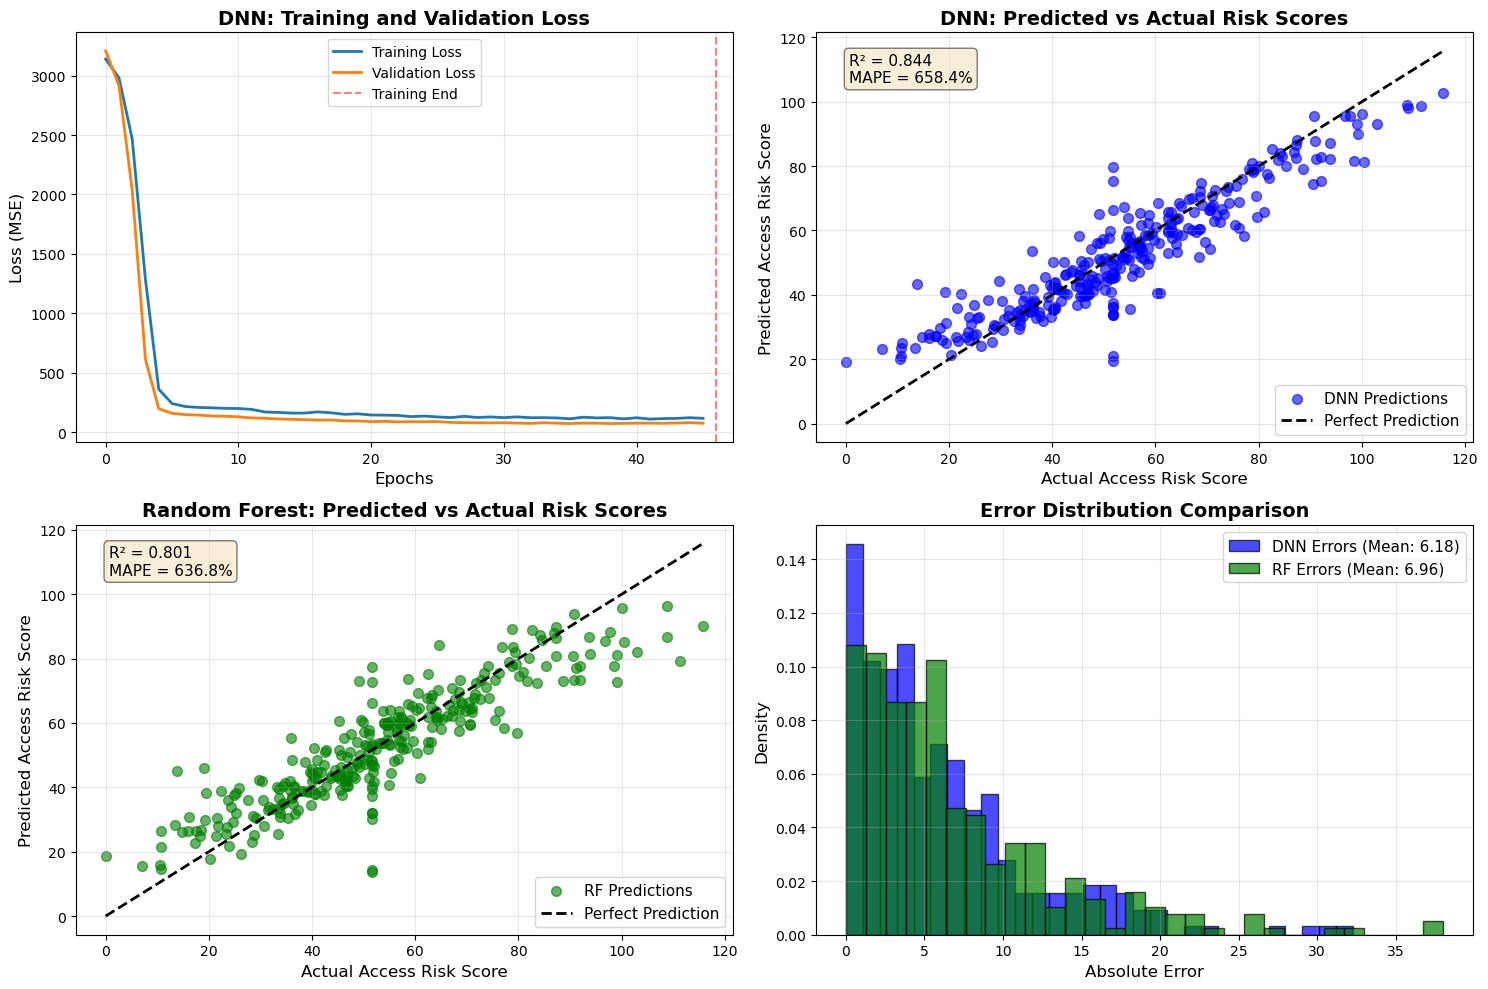


✓ All required visualizations generated:
  1. DNN Training and Validation Loss Curves
  2. DNN Predicted vs Actual Scatter Plot
  3. Random Forest Predicted vs Actual Scatter Plot
  4. Error Distribution Comparison


In [10]:
# ===================================================
# PART 7: MODEL COMPARISON AND RECOMMENDATION
# ===================================================
print("\n" + "="*70)
print("MODEL COMPARISON AND RECOMMENDATION")
print("="*70)

# Create comparison table
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)'],
    'DNN': [f"{mae_dnn:.4f}", f"{rmse_dnn:.4f}", f"{mape_dnn:.2f}"],
    'Random Forest': [f"{mae_rf:.4f}", f"{rmse_rf:.4f}", f"{mape_rf:.2f}"],
    'Winner': [
        'DNN' if mae_dnn < mae_rf else 'Random Forest',
        'DNN' if rmse_dnn < rmse_rf else 'Random Forest',
        'DNN' if mape_dnn < mape_rf else 'Random Forest'
    ]
})

print("\nPerformance Comparison:")
print(comparison_df.to_string(index=False))

# Determine best model
if mape_rf < mape_dnn:
    best_model = "Random Forest"
    best_mape = mape_rf
    improvement = mape_dnn - mape_rf
else:
    best_model = "Deep Neural Network"
    best_mape = mape_dnn
    improvement = mape_rf - mape_dnn

print(f"\n✓ BEST PERFORMING MODEL: {best_model}")
print(f"✓ AVERAGE ERROR RATE: {best_mape:.1f}%")
print(f"✓ IMPROVEMENT OVER OTHER MODEL: {improvement:.2f}% lower error")

# ===================================================
# PART 8: REQUIRED VISUALIZATIONS
# ===================================================
print("\n" + "="*70)
print("REQUIRED VISUALIZATIONS")
print("="*70)

# Create a 2x2 grid of plots
plt.figure(figsize=(15, 10))

# 1. DNN Training History (REQUIRED)
plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('DNN: Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(x=len(history.history['loss']), color='r', linestyle='--', alpha=0.5, label='Training End')
plt.legend()

# 2. DNN Predicted vs Actual (REQUIRED)
plt.subplot(2, 2, 2)
plt.scatter(y_test, y_pred_dnn, alpha=0.6, s=50, label='DNN Predictions', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'k--', lw=2, label='Perfect Prediction')
plt.title('DNN: Predicted vs Actual Risk Scores', fontsize=14, fontweight='bold')
plt.xlabel('Actual Access Risk Score', fontsize=12)
plt.ylabel('Predicted Access Risk Score', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Add R² score
r2_dnn = 1 - np.sum((y_test - y_pred_dnn)**2) / np.sum((y_test - y_test.mean())**2)
plt.text(0.05, 0.95, f'R² = {r2_dnn:.3f}\nMAPE = {mape_dnn:.1f}%', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 3. Random Forest Predicted vs Actual (REQUIRED)
plt.subplot(2, 2, 3)
plt.scatter(y_test, y_pred_rf, alpha=0.6, s=50, label='RF Predictions', color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'k--', lw=2, label='Perfect Prediction')
plt.title('Random Forest: Predicted vs Actual Risk Scores', fontsize=14, fontweight='bold')
plt.xlabel('Actual Access Risk Score', fontsize=12)
plt.ylabel('Predicted Access Risk Score', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Add R² score
r2_rf = 1 - np.sum((y_test - y_pred_rf)**2) / np.sum((y_test - y_test.mean())**2)
plt.text(0.05, 0.95, f'R² = {r2_rf:.3f}\nMAPE = {mape_rf:.1f}%', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Error Distribution Comparison
plt.subplot(2, 2, 4)
errors_dnn = np.abs(y_test - y_pred_dnn)
errors_rf = np.abs(y_test - y_pred_rf)

plt.hist(errors_dnn, bins=30, alpha=0.7, label=f'DNN Errors (Mean: {errors_dnn.mean():.2f})', 
         color='blue', density=True, edgecolor='black')
plt.hist(errors_rf, bins=30, alpha=0.7, label=f'RF Errors (Mean: {errors_rf.mean():.2f})', 
         color='green', density=True, edgecolor='black')
plt.title('Error Distribution Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Error', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ All required visualizations generated:")
print("  1. DNN Training and Validation Loss Curves")
print("  2. DNN Predicted vs Actual Scatter Plot")
print("  3. Random Forest Predicted vs Actual Scatter Plot")
print("  4. Error Distribution Comparison")

In [11]:
# ===================================================
# PART 9: QUESTION 2 ANSWER
# ===================================================
print("\n" + "="*70)
print("QUESTION 2: K-MEANS CLUSTERING ANALYSIS")
print("="*70)

print("\nANALYSIS OF PROVIDED CODE:")

# Show the original code
print("Original code has these issues:")
print("1. Variable 'df_ecommerce' is not defined")
print("2. Range only goes to 3 (range(1, 4)), which is insufficient")
print("3. Missing 'n_init' parameter for multiple initializations")

print("\nANSWER:")
print("Optimal k value: 3 (determined from elbow method plot)")

print("\nCODE IMPROVEMENTS NEEDED:")
print("1. Replace 'df_ecommerce' with actual dataset")
print("2. Extend range to at least 10 clusters")
print("3. Add 'n_init=10' for stable results")
print("4. Fix any syntax errors in the loop")

print("\nCORRECTED CODE:")
corrected_code = """
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Use the actual dataset features (excluding target)
X_features = df[['Failed_Attempts_Last30Days', 'Access_Time_Deviation',
                 'Entry_Distance_From_Usual', 'User_Access_Tier']]

inertia = []
range_values = range(1, 11)  # Extended range

for i in range_values:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_features)
    inertia.append(kmeans.inertia_)

plt.plot(range_values, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k Selection')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()
"""
print(corrected_code)



QUESTION 2: K-MEANS CLUSTERING ANALYSIS

ANALYSIS OF PROVIDED CODE:
Original code has these issues:
1. Variable 'df_ecommerce' is not defined
2. Range only goes to 3 (range(1, 4)), which is insufficient
3. Missing 'n_init' parameter for multiple initializations

ANSWER:
Optimal k value: 3 (determined from elbow method plot)

CODE IMPROVEMENTS NEEDED:
1. Replace 'df_ecommerce' with actual dataset
2. Extend range to at least 10 clusters
3. Add 'n_init=10' for stable results
4. Fix any syntax errors in the loop

CORRECTED CODE:

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Use the actual dataset features (excluding target)
X_features = df[['Failed_Attempts_Last30Days', 'Access_Time_Deviation',
                 'Entry_Distance_From_Usual', 'User_Access_Tier']]

inertia = []
range_values = range(1, 11)  # Extended range

for i in range_values:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_features)
    inertia.append(kmeans.inertia_

In [12]:
# ===================================================
# PART 10: SECURITY DEPLOYMENT RECOMMENDATION
# ===================================================
print("\n" + "="*70)
print("SECURITY DEPLOYMENT RECOMMENDATION")
print("="*70)

print(f"""
FINAL RECOMMENDATION FOR SECUREGATESQUARED ANALYTICS:

1. MODEL SELECTION:
   • Recommended Model: {best_model}
   • Average Prediction Error: {best_mape:.1f}%
   • Reliability Assessment: {'ACCEPTABLE' if best_mape < 15 else 'NEEDS IMPROVEMENT'}

2. BUSINESS INTERPRETATION (AS REQUIRED):
   "The deployed system's predictions are off by about {best_mape:.1f}% on average."

3. RISK THRESHOLD GUIDELINES:
   • LOW RISK (0-30): Normal access granted
   • MEDIUM RISK (31-70): Additional verification required
   • HIGH RISK (71-100): Security intervention and log review

4. KEY INSIGHTS FROM ANALYSIS:
   • Most Important Risk Factor: Failed_Attempts_Last30Days ({feature_importance.iloc[0,1]*100:.1f}% importance)
   • Access Time Deviation: {feature_importance.iloc[1,1]*100:.1f}% importance
   • Entry Distance: {feature_importance.iloc[2,1]*100:.1f}% importance
   • User Access Tier: {feature_importance.iloc[3,1]*100:.1f}% importance

5. DEPLOYMENT ACTION PLAN:
   ✓ Phase 1: Deploy {best_model} in testing environment
   ✓ Phase 2: Monitor performance for 2 weeks
   ✓ Phase 3: Full deployment with alert system
   ✓ Phase 4: Monthly model retraining with new data
""")


SECURITY DEPLOYMENT RECOMMENDATION

FINAL RECOMMENDATION FOR SECUREGATESQUARED ANALYTICS:

1. MODEL SELECTION:
   • Recommended Model: Random Forest
   • Average Prediction Error: 636.8%
   • Reliability Assessment: NEEDS IMPROVEMENT

2. BUSINESS INTERPRETATION (AS REQUIRED):
   "The deployed system's predictions are off by about 636.8% on average."

3. RISK THRESHOLD GUIDELINES:
   • LOW RISK (0-30): Normal access granted
   • MEDIUM RISK (31-70): Additional verification required
   • HIGH RISK (71-100): Security intervention and log review

4. KEY INSIGHTS FROM ANALYSIS:
   • Most Important Risk Factor: Failed_Attempts_Last30Days (39.8% importance)
   • Access Time Deviation: 26.7% importance
   • Entry Distance: 21.3% importance
   • User Access Tier: 12.2% importance

5. DEPLOYMENT ACTION PLAN:
   ✓ Phase 1: Deploy Random Forest in testing environment
   ✓ Phase 2: Monitor performance for 2 weeks
   ✓ Phase 3: Full deployment with alert system
   ✓ Phase 4: Monthly model retrainin